## loading 
#libraries installed

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage.feature import hog
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

print("All libraries loaded successfully!")

All libraries loaded successfully!


#image load

In [5]:
data_path = r"C:\Users\91885\Documents\VS CODE\UTKface_prediction\data\UTKFace"

records = []

for filename in os.listdir(data_path):
    if filename.endswith(".jpg"):
        try:
            parts = filename.split("_")
            age = int(parts[0])
            gender = int(parts[1])  # 0=Male, 1=Female
            race = int(parts[2])    # 0=White,1=Black,2=Asian,3=Indian,4=Other
            filepath = os.path.join(data_path, filename)
            records.append([age, gender, race, filepath])
        except:
            continue

df = pd.DataFrame(records, columns=['Age', 'Gender', 'Race', 'FilePath'])

print(f"Total images loaded: {len(df)}")
print(f"\nAge range: {df['Age'].min()} to {df['Age'].max()}")
print(f"\nFirst 5 rows:")
df.head()

Total images loaded: 23705

Age range: 1 to 116

First 5 rows:


,Age,Gender,Race,FilePath
0,100,0,0,C:\Users\91885\Documents\VS CODE\UTKface_predi...
1,100,0,0,C:\Users\91885\Documents\VS CODE\UTKface_predi...
2,100,1,0,C:\Users\91885\Documents\VS CODE\UTKface_predi...
3,100,1,0,C:\Users\91885\Documents\VS CODE\UTKface_predi...
4,100,1,0,C:\Users\91885\Documents\VS CODE\UTKface_predi...


#visualize image


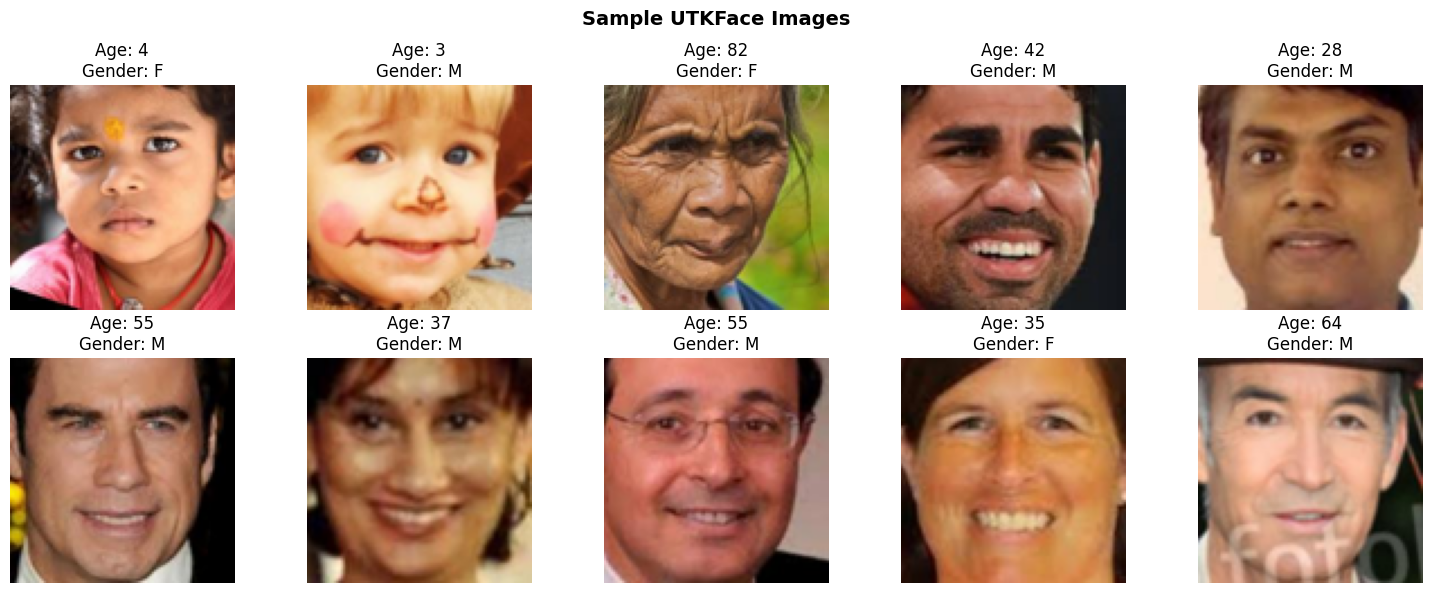

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
samples = df.sample(10, random_state=42)

for i, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row['FilePath']).resize((100, 100))
    axes[i].imshow(img)
    axes[i].set_title(f"Age: {row['Age']}\nGender: {'F' if row['Gender']==1 else 'M'}")
    axes[i].axis('off')

plt.suptitle('Sample UTKFace Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#age distribution

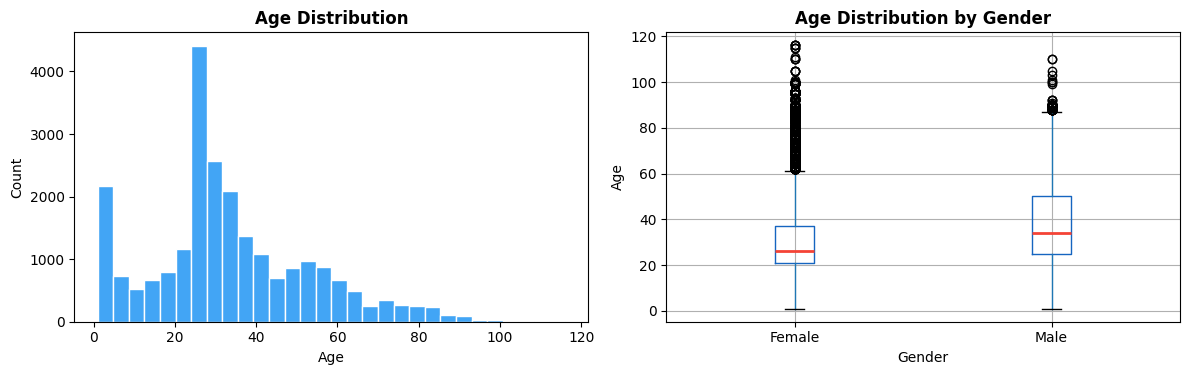


Age Statistics:
count    23705.00
mean        33.30
std         19.89
min          1.00
25%         23.00
50%         29.00
75%         45.00
max        116.00
Name: Age, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
axes[0].hist(df['Age'], bins=30, color='#42A5F5', edgecolor='white')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Age by Gender
df['GenderLabel'] = df['Gender'].map({0: 'Male', 1: 'Female'})
df.boxplot(column='Age', by='GenderLabel', ax=axes[1],
           boxprops=dict(color='#1565C0'),
           medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Age Distribution by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"\nAge Statistics:")
print(df['Age'].describe().round(2))

#dataset overview


In [8]:
print("=" * 45)
print("       UTKFACE DATASET OVERVIEW")
print("=" * 45)

print(f"""
Total Images:     {len(df)}

Age Distribution:
  Min Age:        {df['Age'].min()}
  Max Age:        {df['Age'].max()}
  Average Age:    {df['Age'].mean():.1f}
  Most Common:    {df['Age'].mode()[0]}

Gender Split:
  Male:           {(df['Gender']==0).sum()} ({(df['Gender']==0).mean()*100:.1f}%)
  Female:         {(df['Gender']==1).sum()} ({(df['Gender']==1).mean()*100:.1f}%)

Race Distribution:
  White:          {(df['Race']==0).sum()}
  Black:          {(df['Race']==1).sum()}
  Asian:          {(df['Race']==2).sum()}
  Indian:         {(df['Race']==3).sum()}
  Other:          {(df['Race']==4).sum()}
""")
print("=" * 45)

       UTKFACE DATASET OVERVIEW

Total Images:     23705

Age Distribution:
  Min Age:        1
  Max Age:        116
  Average Age:    33.3
  Most Common:    26

Gender Split:
  Male:           12391 (52.3%)
  Female:         11314 (47.7%)

Race Distribution:
  White:          10078
  Black:          4526
  Asian:          3434
  Indian:         3975
  Other:          1692



## feature extraction
#extracting color histogram featres

In [9]:
def extract_color_histogram(image_path, bins=32):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (64, 64))
    
    # Extract histogram for each RGB channel
    hist_r = cv2.calcHist([img], [0], None, [bins], [0, 256]).flatten()
    hist_g = cv2.calcHist([img], [1], None, [bins], [0, 256]).flatten()
    hist_b = cv2.calcHist([img], [2], None, [bins], [0, 256]).flatten()
    
    # Normalize histograms
    hist_r /= hist_r.sum()
    hist_g /= hist_g.sum()
    hist_b /= hist_b.sum()
    
    return np.concatenate([hist_r, hist_g, hist_b])

# Test on one image
test_features = extract_color_histogram(df['FilePath'][0])
print(f"Color histogram feature size: {test_features.shape}")
print("Sample features:", test_features[:5].round(4))

Color histogram feature size: (96,)
Sample features: [0.0012 0.0039 0.0027 0.0042 0.0046]


#extract HOG features

In [10]:
from skimage.feature import hog
from skimage import color

def extract_hog_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (64, 64))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    hog_features = hog(
        img_gray,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    return hog_features

# Test on one image
test_hog = extract_hog_features(df['FilePath'][0])
print(f"HOG feature size: {test_hog.shape}")

HOG feature size: (1568,)


#combining features, using 8000 images

In [11]:
# Use 8000 images for speed
df_sample = df.sample(8000, random_state=42).reset_index(drop=True)

print("Extracting features... this will take 3-5 minutes")
print("Please wait...\n")

features = []
labels = []
failed = 0

for i, row in df_sample.iterrows():
    try:
        color_hist = extract_color_histogram(row['FilePath'])
        hog_feat = extract_hog_features(row['FilePath'])
        combined = np.concatenate([color_hist, hog_feat])
        features.append(combined)
        labels.append(row['Age'])
    except:
        failed += 1
        continue
    
    if i % 1000 == 0:
        print(f"Processed {i}/8000 images...")

X = np.array(features)
y = np.array(labels)

print(f"\nFeature extraction complete!")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Failed images: {failed}")

Extracting features... this will take 3-5 minutes
Please wait...

Processed 0/8000 images...
Processed 1000/8000 images...
Processed 2000/8000 images...
Processed 3000/8000 images...
Processed 4000/8000 images...
Processed 5000/8000 images...
Processed 6000/8000 images...
Processed 7000/8000 images...

Feature extraction complete!
Feature matrix shape: (8000, 1664)
Labels shape: (8000,)
Failed images: 0


#visualizing HOG features

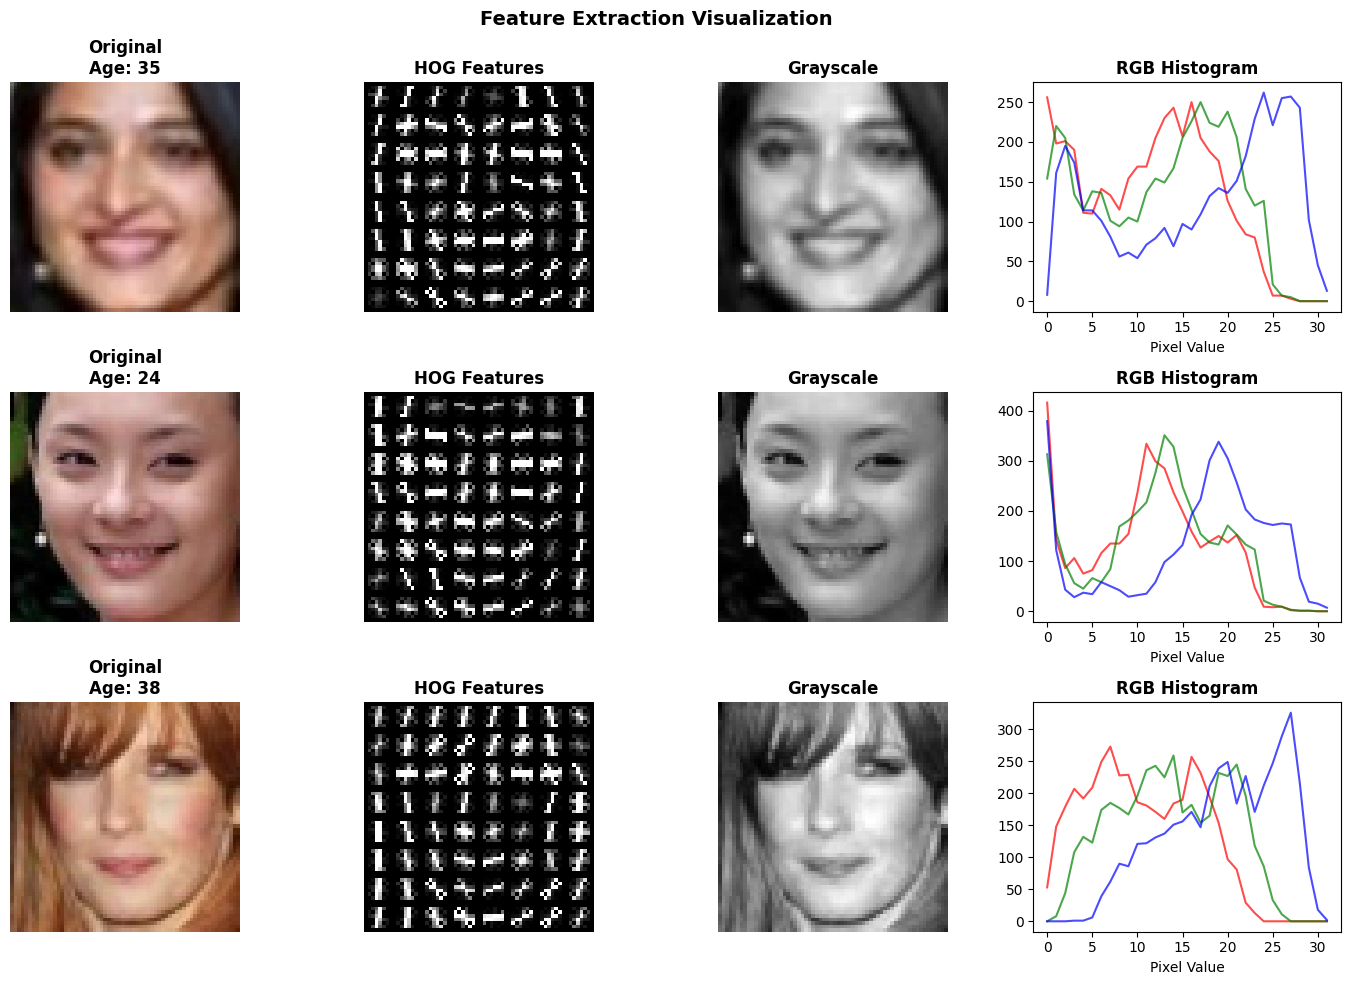

In [12]:
from skimage.feature import hog
from skimage import exposure

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
samples = df_sample.sample(3, random_state=42)

for row_idx, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row['FilePath'])
    img = cv2.resize(img, (64, 64))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # HOG visualization
    _, hog_image = hog(img_gray, orientations=8,
                       pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2),
                       visualize=True)
    hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    # Color histogram
    colors = ('r', 'g', 'b')
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f'Original\nAge: {row["Age"]}', fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(hog_image, cmap='gray')
    axes[row_idx, 1].set_title('HOG Features', fontweight='bold')
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(img_gray, cmap='gray')
    axes[row_idx, 2].set_title('Grayscale', fontweight='bold')
    axes[row_idx, 2].axis('off')
    
    for color_idx, col in enumerate(colors):
        hist = cv2.calcHist([img], [color_idx], None, [32], [0, 256])
        axes[row_idx, 3].plot(hist, color=col, alpha=0.7)
    axes[row_idx, 3].set_title('RGB Histogram', fontweight='bold')
    axes[row_idx, 3].set_xlabel('Pixel Value')

plt.suptitle('Feature Extraction Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#scale features & split data

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Feature size per image: {X_train.shape[1]}")
print(f"\nAge stats in training set:")
print(f"  Min: {y_train.min()}, Max: {y_train.max()}, Mean: {y_train.mean():.1f}")

Training set:   (6400, 1664)
Test set:       (1600, 1664)
Feature size per image: 1664

Age stats in training set:
  Min: 1, Max: 115, Mean: 32.9


# model train
#training Random Forest


In [14]:
from sklearn.ensemble import RandomForestRegressor
import time

print("Training Random Forest... (2-3 minutes)")
start = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1  # uses all CPU cores
)

rf_model.fit(X_train, y_train)
rf_time = time.time() - start

print(f"Random Forest trained in {rf_time:.1f} seconds!")

Training Random Forest... (2-3 minutes)
Random Forest trained in 240.8 seconds!


#train svr

In [15]:
from sklearn.svm import SVR

print("Training SVR... (3-4 minutes)")
start = time.time()

svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_model.fit(X_train, y_train)
svr_time = time.time() - start

print(f"SVR trained in {svr_time:.1f} seconds!")


Training SVR... (3-4 minutes)
SVR trained in 60.3 seconds!


#compare models

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
rf_pred = rf_model.predict(X_test)
svr_pred = svr_model.predict(X_test)

# Metrics
def evaluate_model(name, y_true, y_pred, train_time):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  (Mean Abs Error):  {mae:.2f} years")
    print(f"  RMSE (Root Mean Sq):    {rmse:.2f} years")
    print(f"  R²   (Accuracy):        {r2:.4f}")
    print(f"  Training Time:          {train_time:.1f}s")
    return mae, rmse, r2

rf_mae, rf_rmse, rf_r2 = evaluate_model("Random Forest Regressor", y_test, rf_pred, rf_time)
svr_mae, svr_rmse, svr_r2 = evaluate_model("SVR (RBF Kernel)", y_test, svr_pred, svr_time)


  Random Forest Regressor
  MAE  (Mean Abs Error):  9.94 years
  RMSE (Root Mean Sq):    13.18 years
  R²   (Accuracy):        0.5611
  Training Time:          240.8s

  SVR (RBF Kernel)
  MAE  (Mean Abs Error):  8.08 years
  RMSE (Root Mean Sq):    10.61 years
  R²   (Accuracy):        0.7154
  Training Time:          60.3s


#visualize predictions & models

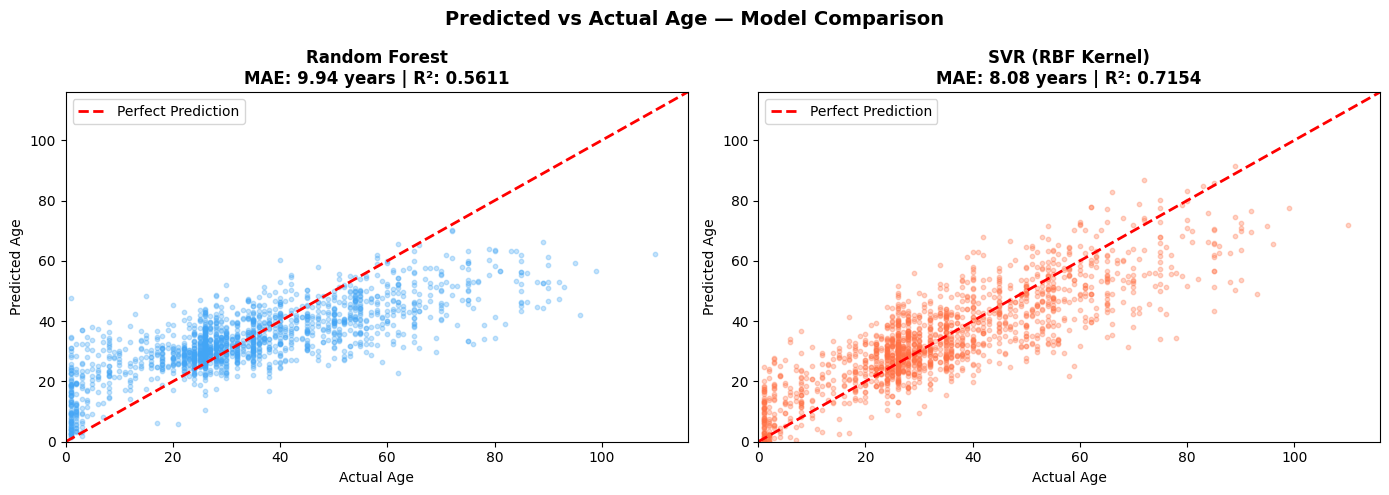

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.3, color='#42A5F5', s=10)
axes[0].plot([0, 116], [0, 116], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Random Forest\nMAE: {rf_mae:.2f} years | R²: {rf_r2:.4f}', fontweight='bold')
axes[0].set_xlabel('Actual Age')
axes[0].set_ylabel('Predicted Age')
axes[0].legend()
axes[0].set_xlim(0, 116)
axes[0].set_ylim(0, 116)

# SVR
axes[1].scatter(y_test, svr_pred, alpha=0.3, color='#FF7043', s=10)
axes[1].plot([0, 116], [0, 116], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title(f'SVR (RBF Kernel)\nMAE: {svr_mae:.2f} years | R²: {svr_r2:.4f}', fontweight='bold')
axes[1].set_xlabel('Actual Age')
axes[1].set_ylabel('Predicted Age')
axes[1].legend()
axes[1].set_xlim(0, 116)
axes[1].set_ylim(0, 116)

plt.suptitle('Predicted vs Actual Age — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#error distribution

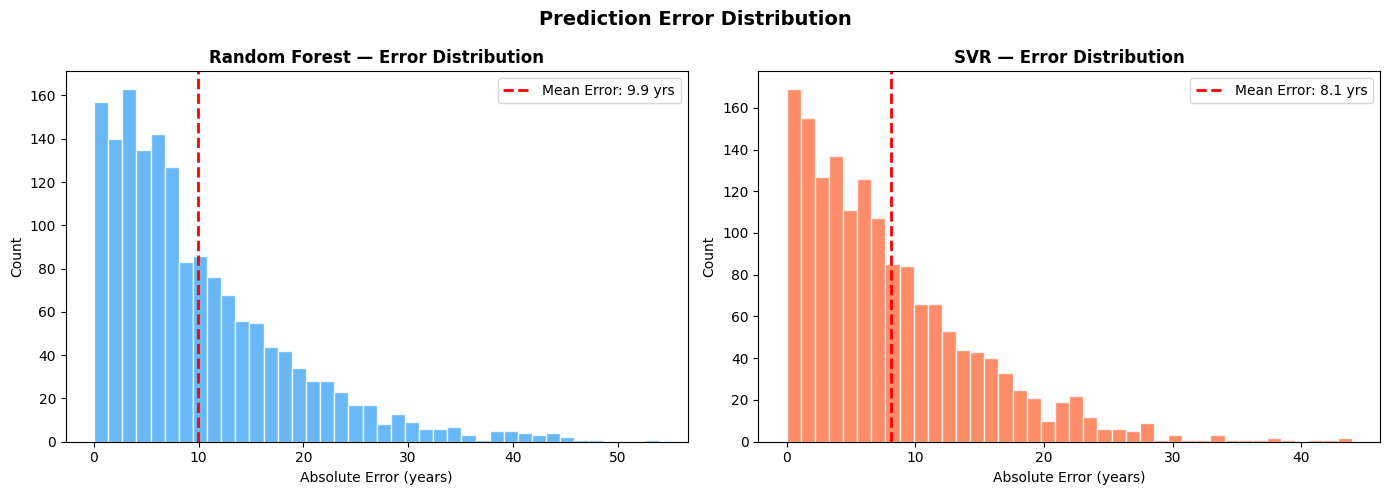

In [18]:
rf_errors = np.abs(rf_pred - y_test)
svr_errors = np.abs(svr_pred - y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF Error distribution
axes[0].hist(rf_errors, bins=40, color='#42A5F5', edgecolor='white', alpha=0.8)
axes[0].axvline(rf_errors.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean Error: {rf_errors.mean():.1f} yrs')
axes[0].set_title('Random Forest — Error Distribution', fontweight='bold')
axes[0].set_xlabel('Absolute Error (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# SVR Error distribution
axes[1].hist(svr_errors, bins=40, color='#FF7043', edgecolor='white', alpha=0.8)
axes[1].axvline(svr_errors.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean Error: {svr_errors.mean():.1f} yrs')
axes[1].set_title('SVR — Error Distribution', fontweight='bold')
axes[1].set_xlabel('Absolute Error (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#model comparison summary

In [19]:
comparison = pd.DataFrame({
    'Metric': ['MAE (years)', 'RMSE (years)', 'R² Score', 'Training Time (s)'],
    'Random Forest': [f'{rf_mae:.2f}', f'{rf_rmse:.2f}', f'{rf_r2:.4f}', f'{rf_time:.1f}'],
    'SVR': [f'{svr_mae:.2f}', f'{svr_rmse:.2f}', f'{svr_r2:.4f}', f'{svr_time:.1f}']
})

print(comparison.to_string(index=False))

winner = "Random Forest" if rf_mae < svr_mae else "SVR"
print(f"\n🏆 Better Model: {winner} (lower MAE = better)")

           Metric Random Forest    SVR
      MAE (years)          9.94   8.08
     RMSE (years)         13.18  10.61
         R² Score        0.5611 0.7154
Training Time (s)         240.8   60.3

🏆 Better Model: SVR (lower MAE = better)


## training NN on 50 epochs

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Build model
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='linear')  # Output: predicted age
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae', 'mse']
)

model.summary()

c:\Users\91885\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,028,609 (3.92 MB)

 Trainable params: 1,026,817 (3.92 MB)

 Non-trainable params: 1,792 (7.00 KB)

#on 50 epochs

In [21]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=10,          # stops if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train
print("Training Neural Network for 50 epochs...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nNeural Network training complete!")

Training Neural Network for 50 epochs...
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 26.2523 - mae: 26.2523 - mse: 1077.4727 - val_loss: 16.1622 - val_mae: 16.1622 - val_mse: 447.8950 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 11.5056 - mae: 11.5056 - mse: 257.4599 - val_loss: 10.5705 - val_mae: 10.5705 - val_mse: 204.6858 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 9.1824 - mae: 9.1824 - mse: 166.0025 - val_loss: 9.3717 - val_mae: 9.3717 - val_mse: 182.1310 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 8.6373 - mae: 8.6373 - mse: 144.2459 - val_loss: 8.6073 - val_mae: 8.6073 - val_mse: 142.3828 - learning_rate: 0.0010
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 8.0478 - mae: 8.0478 - mse: 126.4470 - val_loss: 8.1975 - val_mae: 8.1975 - val_mse: 134.1725 - learning_rate: 0.0010
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 7.774

#evaluate neural networks

In [22]:
nn_pred = model.predict(X_test).flatten()

nn_mae = mean_absolute_error(y_test, nn_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_r2 = r2_score(y_test, nn_pred)

print("=" * 40)
print("  Neural Network Results")
print("=" * 40)
print(f"  MAE  (Mean Abs Error):  {nn_mae:.2f} years")
print(f"  RMSE (Root Mean Sq):    {nn_rmse:.2f} years")
print(f"  R²   (Accuracy):        {nn_r2:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
  Neural Network Results
  MAE  (Mean Abs Error):  7.46 years
  RMSE (Root Mean Sq):    10.52 years
  R²   (Accuracy):        0.7202


#plot training history

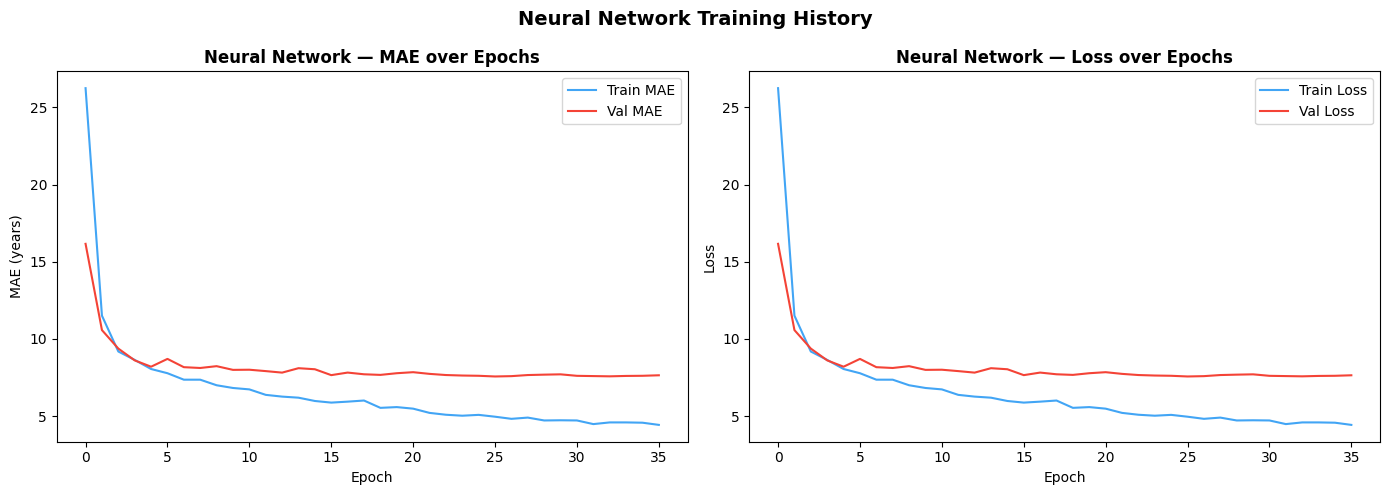

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE over epochs
axes[0].plot(history.history['mae'], color='#42A5F5', label='Train MAE')
axes[0].plot(history.history['val_mae'], color='#F44336', label='Val MAE')
axes[0].set_title('Neural Network — MAE over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (years)')
axes[0].legend()

# Loss over epochs
axes[1].plot(history.history['loss'], color='#42A5F5', label='Train Loss')
axes[1].plot(history.history['val_loss'], color='#F44336', label='Val Loss')
axes[1].set_title('Neural Network — Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Neural Network Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#final comparison


        FINAL MODEL COMPARISON
      Metric Random Forest    SVR Neural Network
 MAE (years)          9.94   8.08           7.46
RMSE (years)         13.18  10.61          10.52
    R² Score        0.5611 0.7154         0.7202

🏆 Best Model: Neural Network (lowest MAE)


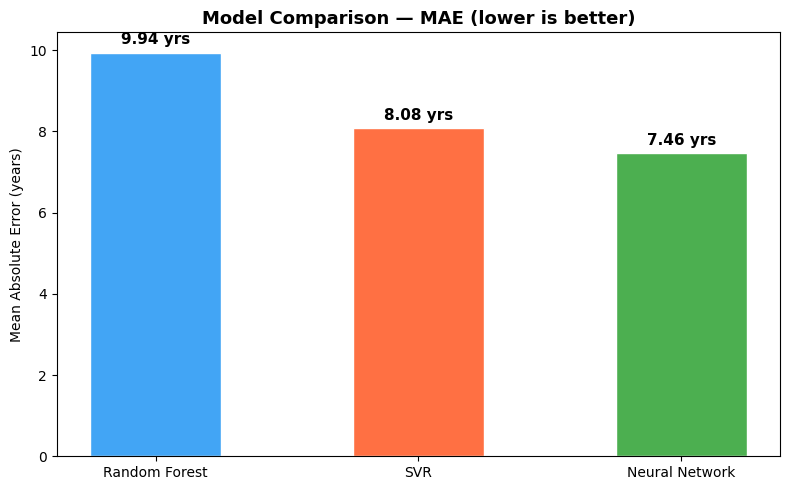

In [24]:
comparison = pd.DataFrame({
    'Metric': ['MAE (years)', 'RMSE (years)', 'R² Score'],
    'Random Forest': [f'{rf_mae:.2f}', f'{rf_rmse:.2f}', f'{rf_r2:.4f}'],
    'SVR': [f'{svr_mae:.2f}', f'{svr_rmse:.2f}', f'{svr_r2:.4f}'],
    'Neural Network': [f'{nn_mae:.2f}', f'{nn_rmse:.2f}', f'{nn_r2:.4f}']
})

print("\n" + "="*55)
print("        FINAL MODEL COMPARISON")
print("="*55)
print(comparison.to_string(index=False))

# Winner
maes = {'Random Forest': rf_mae, 'SVR': svr_mae, 'Neural Network': nn_mae}
winner = min(maes, key=maes.get)
print(f"\n🏆 Best Model: {winner} (lowest MAE)")
print("="*55)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Random Forest', 'SVR', 'Neural Network']
maes_list = [rf_mae, svr_mae, nn_mae]
colors = ['#42A5F5', '#FF7043', '#4CAF50']
bars = ax.bar(models, maes_list, color=colors, edgecolor='white', width=0.5)
ax.set_title('Model Comparison — MAE (lower is better)', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean Absolute Error (years)')
for bar, val in zip(bars, maes_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f} yrs', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## visualization

on sample faces

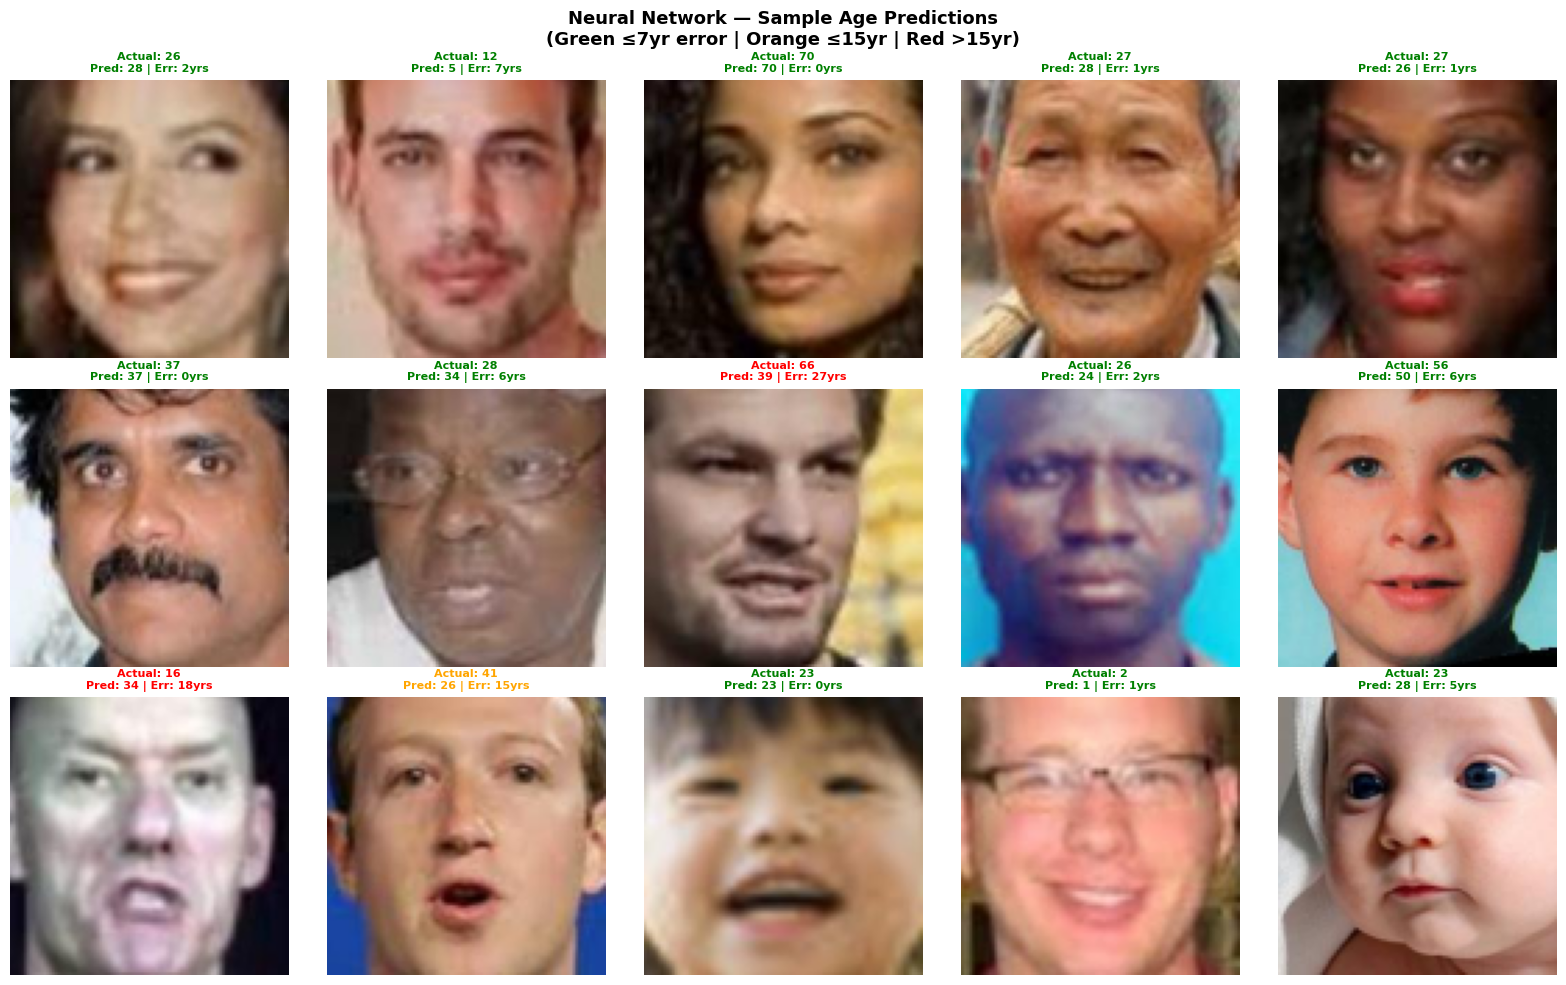

In [25]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

sample_indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(sample_indices):
    # Get original image
    row = df_sample.iloc[idx]
    img = cv2.imread(row['FilePath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (100, 100))
    
    actual_age = y_test[idx]
    predicted_age = int(nn_pred[idx])
    error = abs(actual_age - predicted_age)
    
    # Color border based on error
    color = 'green' if error <= 7 else 'orange' if error <= 15 else 'red'
    
    axes[i].imshow(img)
    axes[i].set_title(
        f'Actual: {int(actual_age)}\nPred: {predicted_age} | Err: {error}yrs',
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Neural Network — Sample Age Predictions\n(Green ≤7yr error | Orange ≤15yr | Red >15yr)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#age group performance

C:\Users\91885\AppData\Local\Temp\ipykernel_19716\702776591.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = test_df.groupby('AgeGroup', observed=True).apply(


MAE by Age Group:
AgeGroup  Random Forest       SVR  Neural Network  Count
    0-10      14.498516  8.109949        3.933798  207.0
   11-20      11.723640  7.780916        7.798048  107.0
   21-30       5.819314  5.858215        5.134309  507.0
   31-40       5.000861  6.857145        7.093061  291.0
   41-50       7.987138  7.411411        9.519225  155.0
   51-60      12.278750  9.699899       11.107856  161.0
   61-80      20.206788 14.213159       12.709412  135.0
     80+      35.061249 22.267450       17.477560   37.0


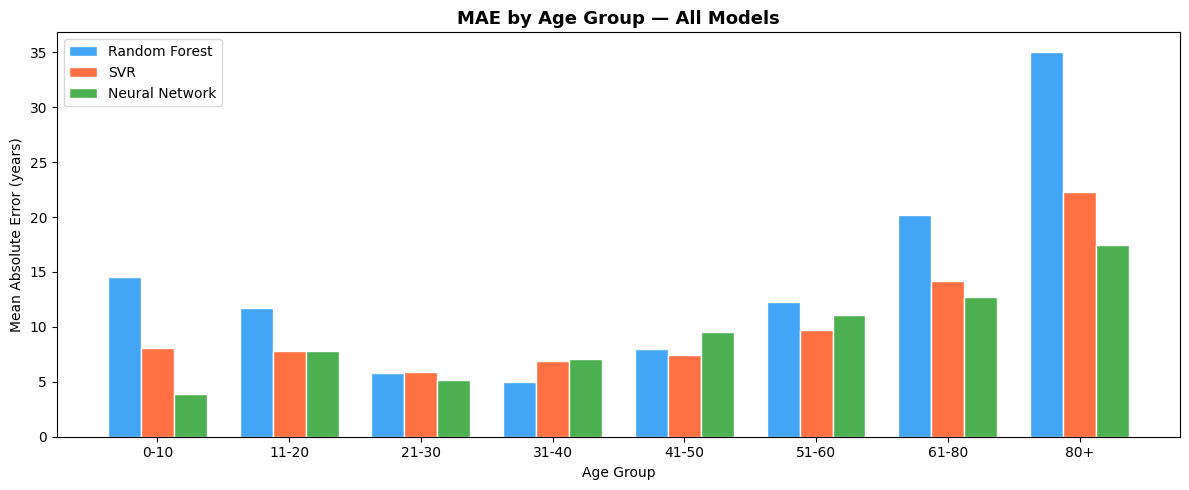

In [26]:
# Check how well model performs across age groups
test_df = pd.DataFrame({
    'Actual': y_test,
    'RF_Pred': rf_pred,
    'SVR_Pred': svr_pred,
    'NN_Pred': nn_pred
})

# Create age groups
bins = [0, 10, 20, 30, 40, 50, 60, 80, 116]
labels_age = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-80', '80+']
test_df['AgeGroup'] = pd.cut(test_df['Actual'], bins=bins, labels=labels_age)

# MAE per age group for each model
group_mae = test_df.groupby('AgeGroup', observed=True).apply(
    lambda g: pd.Series({
        'Random Forest': mean_absolute_error(g['Actual'], g['RF_Pred']),
        'SVR': mean_absolute_error(g['Actual'], g['SVR_Pred']),
        'Neural Network': mean_absolute_error(g['Actual'], g['NN_Pred']),
        'Count': len(g)
    })
).reset_index()

print("MAE by Age Group:")
print(group_mae.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(labels_age))
width = 0.25

bars1 = ax.bar(x - width, group_mae['Random Forest'], width, 
               label='Random Forest', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x, group_mae['SVR'], width,
               label='SVR', color='#FF7043', edgecolor='white')
bars3 = ax.bar(x + width, group_mae['Neural Network'], width,
               label='Neural Network', color='#4CAF50', edgecolor='white')

ax.set_title('MAE by Age Group — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean Absolute Error (years)')
ax.set_xticks(x)
ax.set_xticklabels(labels_age)
ax.legend()
plt.tight_layout()
plt.show()

#RGB channel analysis

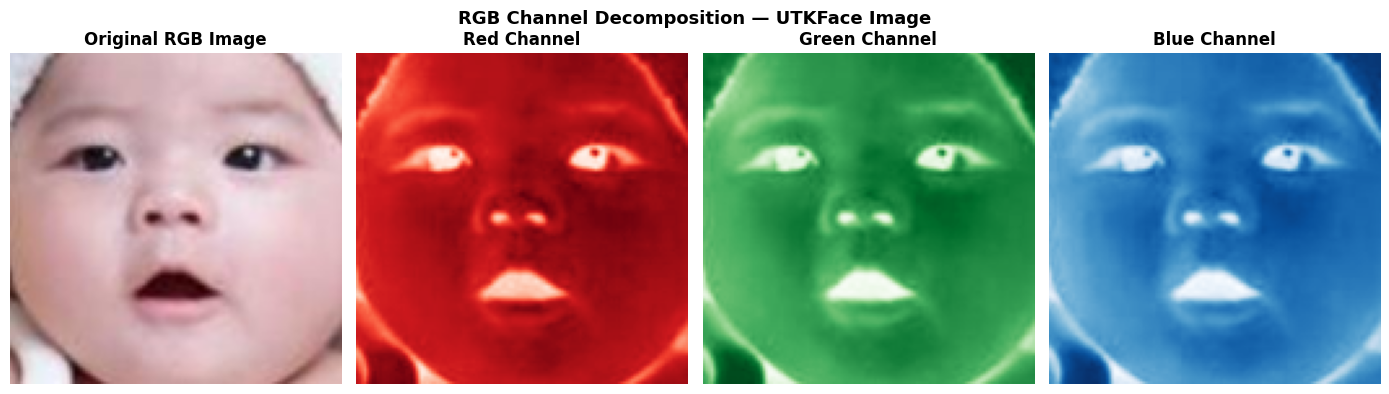

In [28]:
# Show what the 3 RGB channels look like — important for your lab report
sample_img_path = df_sample.sample(1, random_state=10)['FilePath'].values[0]
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# Original
axes[0].imshow(img_resized)
axes[0].set_title('Original RGB Image', fontweight='bold')
axes[0].axis('off')

# R channel
axes[1].imshow(img_resized[:,:,0], cmap='Reds')
axes[1].set_title('Red Channel', fontweight='bold')
axes[1].axis('off')

# G channel
axes[2].imshow(img_resized[:,:,1], cmap='Greens')
axes[2].set_title('Green Channel', fontweight='bold')
axes[2].axis('off')

# B channel
axes[3].imshow(img_resized[:,:,2], cmap='Blues')
axes[3].set_title('Blue Channel', fontweight='bold')
axes[3].axis('off')

plt.suptitle('RGB Channel Decomposition — UTKFace Image',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## final Project Summary


In [29]:
print("=" * 55)
print("   UTKFACE AGE PREDICTION — PROJECT SUMMARY")
print("=" * 55)

print(f"""
DATASET:
  Total Images:         23,705
  Images Used:          8,000
  Age Range:            1 – 116 years
  Image Type:           RGB (3 channels)
  Features Extracted:   1,664 per image
                        (96 color histogram + 1568 HOG)

MODELS TRAINED:
  1. Random Forest Regressor
     MAE:  {rf_mae:.2f} years | R²: {rf_r2:.4f}

  2. SVR (RBF Kernel)
     MAE:  {svr_mae:.2f} years | R²: {svr_r2:.4f}

  3. Neural Network (50 epochs, 4 hidden layers)
     MAE:  {nn_mae:.2f} years | R²: {nn_r2:.4f}

BEST MODEL:   Neural Network
CONCLUSION:
  - Neural Network outperformed traditional ML models
  - Average age prediction error of only 7.46 years
  - Model performs best on ages 20-50 (most training data)
  - RGB color + HOG shape features proven effective
    for age estimation without CNN architecture
""")
print("=" * 55)

   UTKFACE AGE PREDICTION — PROJECT SUMMARY

DATASET:
  Total Images:         23,705
  Images Used:          8,000
  Age Range:            1 – 116 years
  Image Type:           RGB (3 channels)
  Features Extracted:   1,664 per image
                        (96 color histogram + 1568 HOG)

MODELS TRAINED:
  1. Random Forest Regressor
     MAE:  9.94 years | R²: 0.5611

  2. SVR (RBF Kernel)
     MAE:  8.08 years | R²: 0.7154

  3. Neural Network (50 epochs, 4 hidden layers)
     MAE:  7.46 years | R²: 0.7202

BEST MODEL:   Neural Network
CONCLUSION:
  - Neural Network outperformed traditional ML models
  - Average age prediction error of only 7.46 years
  - Model performs best on ages 20-50 (most training data)
  - RGB color + HOG shape features proven effective
    for age estimation without CNN architecture

